In [ ]:
!pip install datasets sentence-transformers -q

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps "trl<0.9.0" peft accelerate bitsandbytes xformers datasets -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import unsloth
from unsloth import FastLanguageModel
import torch

In [ ]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

In [ ]:
print(train_data[8])

{'text': 'i have been with petronas for years i feel that petronas has performed well and made a huge profit', 'label': 1}


In [ ]:
X_train_pre = train_data["text"]
y_train = train_data["label"]

X_val_pre = val_data["text"]
y_val = val_data["label"]

X_test_pre = test_data["text"]
y_test = test_data["label"]

In [ ]:
label_names = dataset["train"].features["label"].names
print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [ ]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("SamLowe/roberta-base-go_emotions")

X_train = embed_model.encode(X_train_pre, show_progress_bar=True)
X_val = embed_model.encode(X_val_pre, show_progress_bar=True)
X_test = embed_model.encode(X_test_pre, show_progress_bar=True)

print(X_train.shape)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     | 
--------------------------------+------------+-
classifier.dense.bias           | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Batches:   0%|          | 0/500 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

(16000, 768)


In [ ]:
input_dim = X_train.shape[1]  # should be 384
num_classes = len(label_names)  # 6
print(input_dim)
print(num_classes)

768
6


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

MLP_model = MLPClassifier(input_dim=input_dim, num_classes=num_classes)

In [ ]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)

Epoch 0: train loss=1.1771, val loss=1.0703, val acc=0.6830
Epoch 10: train loss=0.9524, val loss=0.9599, val acc=0.7350
Epoch 20: train loss=0.8642, val loss=0.9494, val acc=0.7470
Epoch 30: train loss=0.7874, val loss=0.9372, val acc=0.7595
Epoch 40: train loss=0.7282, val loss=0.9481, val acc=0.7565


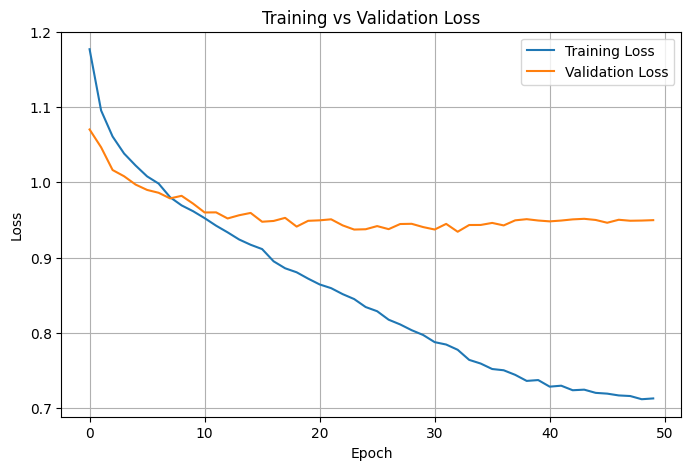

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(MLP_model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

batch_size = 100

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_losses = []
val_losses = []

for epoch in range(50):

    MLP_model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = MLP_model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

    scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataset)

    MLP_model.eval()
    with torch.no_grad():
        val_outputs = MLP_model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

        preds = torch.argmax(val_outputs, dim=1)
        val_acc = (preds == y_val_t).float().mean().item()

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}: "
            f"train loss={avg_train_loss:.4f}, "
            f"val loss={val_loss.item():.4f}, "
            f"val acc={val_acc:.4f}"
        )



plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
MLP_model.eval()

with torch.no_grad():
    logits = MLP_model(X_val_t)   # or X_test_t if you have it
    preds = torch.argmax(logits, dim=1)

y_true = y_val_t.cpu().numpy()
y_pred = preds.cpu().numpy()

MLP_accuracy = accuracy_score(y_true, y_pred)

MLP_precision, MLP_recall, MLP_f1, MLP_support = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("MLP Results")
print("Accuracy:", MLP_accuracy)
print("Macro Precision:", MLP_precision)
print("Macro Recall:", MLP_recall)
print("Macro F1:", MLP_f1)

MLP Results
Accuracy: 0.754
Macro Precision: 0.7317860830421319
Macro Recall: 0.7039769718895311
Macro F1: 0.7150912797283255


In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps "trl<0.9.0" peft accelerate bitsandbytes xformers datasets -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:


max_seq_length = 1024
dtype = None
load_in_4bit = True

llm_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit
)

FastLanguageModel.for_inference(llm_model)

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128255)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm):

In [ ]:
def make_prompt(text):
    return f"""
    Class Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

    text: {text}
    """

In [ ]:
def ask_llm_unsloth(prompt):
    full_prompt = f"""### Instruction:
You are a precise classifier. Return only one class label from the provided list and a confidence level.

Follow this exact format:
label | confidence


The confidence must be a number from 0 to 1 and the label must be one of the provided class labels.

No Explanations
### Input:
{prompt}

### Answer:
"""

    inputs = tokenizer(
        full_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to("cuda")
    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "### Answer:" in decoded:
        decoded = decoded.split("### Answer:")[-1]

    response = decoded.strip()
    parts = response.split("|")
    if len(parts) == 2:
        label, confidence = parts
        confidence = float(confidence.strip())
    return label, confidence

In [ ]:
import random




rand_indices = random.sample(range(len(X_test_pre)), 100)

predicted = []
actual = []
confidences = []
step = 0
for idx in rand_indices:
    prompt = make_prompt(X_test_pre[idx])
    predicted_label, confidence = ask_llm_unsloth(prompt)
    correct_label = label_names[y_test[idx]]
    if step % 25 == 0:
        print(f"Predicted: {predicted_label} Actual: {correct_label}")
    predicted.append(predicted_label)
    confidences.append(confidence)
    actual.append(correct_label)
    step +=1

LLM_accuracy = accuracy_score(actual, predicted)

LLM_precision, LLM_recall, LLM_f1, support = precision_recall_fscore_support(
    actual,
    predicted,
    average="macro",
    zero_division=0
)

print("Accuracy:", LLM_accuracy)
print("Macro Precision:", LLM_precision)
print("Macro Recall:", LLM_recall)
print("Macro F1:", LLM_f1)

Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=20)

Predicted: sadness  Actual: sadness


Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicted: sadness  Actual: sadness


Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicted: joy  Actual: joy


Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicted: joy  Actual: joy


Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Accuracy: 0.0
Macro Precision: 0.0
Macro Recall: 0.0
Macro F1: 0.0


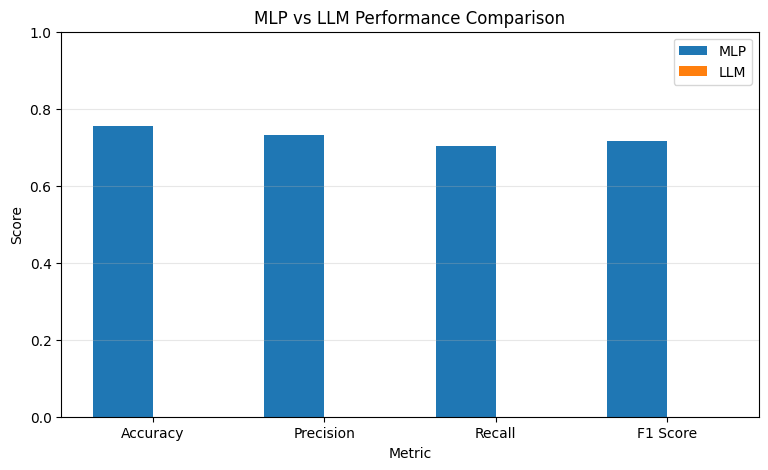

In [ ]:

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

mlp_scores = [
    MLP_accuracy,
    MLP_precision,
    MLP_recall,
    MLP_f1
]

llm_scores = [
    LLM_accuracy,
    LLM_precision,
    LLM_recall,
    LLM_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, mlp_scores, width, label="MLP")
plt.bar(x + width/2, llm_scores, width, label="LLM")

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("MLP vs LLM Performance Comparison")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
most_conf = np.argsort(confidences)[-5:]
least_conf = np.argsort(confidences)[:5]

print("Most Confident Predictions:")
for idx in most_conf:
    print(f"Predicted: {predicted[idx]} Actual: {actual[idx]} Confidence: {confidences[idx]}")

print("\nLeast Confident Predictions:")
for idx in least_conf:
    print(f"Predicted: {predicted[idx]} Actual: {actual[idx]} Confidence: {confidences[idx]}")

Most Confident Predictions:
Predicted: sadness  Actual: surprise Confidence: 0.8
Predicted: sadness  Actual: sadness Confidence: 0.8
Predicted: sadness  Actual: joy Confidence: 0.8
Predicted: sadness  Actual: sadness Confidence: 0.9
Predicted: sadness  Actual: fear Confidence: 0.9

Least Confident Predictions:
Predicted: sadness  Actual: surprise Confidence: 0.5
Predicted: sadness  Actual: joy Confidence: 0.5
Predicted: sadness  Actual: joy Confidence: 0.5
Predicted: sadness  Actual: joy Confidence: 0.5
Predicted: sadness  Actual: fear Confidence: 0.5


In [ ]:

import torch.nn.functional as F


MLP_model.eval()
with torch.no_grad():
    val_outputs = MLP_model(X_val_t)
    probs = F.softmax(val_outputs, dim=1)
    confidences_t, pred_indices = torch.max(probs, dim=1)

confidences = confidences_t.numpy()
predicted = [label_names[i] for i in pred_indices.numpy()]
actual = [label_names[i] for i in y_val_t.numpy()]

most_conf = np.argsort(confidences)[-5:]
least_conf = np.argsort(confidences)[:5]

print("Most Confident Predictions:")
for idx in most_conf:
    print(f"Predicted: {predicted[idx]} Actual: {actual[idx]} Confidence: {confidences[idx]:.4f}")

print("\nLeast Confident Predictions:")
for idx in least_conf:
    print(f"Predicted: {predicted[idx]} Actual: {actual[idx]} Confidence: {confidences[idx]:.4f}")

Most Confident Predictions:
Predicted: surprise Actual: surprise Confidence: 0.9939
Predicted: love Actual: love Confidence: 0.9955
Predicted: anger Actual: anger Confidence: 0.9964
Predicted: surprise Actual: surprise Confidence: 0.9979
Predicted: love Actual: love Confidence: 0.9985

Least Confident Predictions:
Predicted: anger Actual: joy Confidence: 0.2797
Predicted: fear Actual: fear Confidence: 0.2844
Predicted: joy Actual: anger Confidence: 0.2880
Predicted: fear Actual: sadness Confidence: 0.2916
Predicted: sadness Actual: joy Confidence: 0.2921


<Figure size 800x800 with 0 Axes>

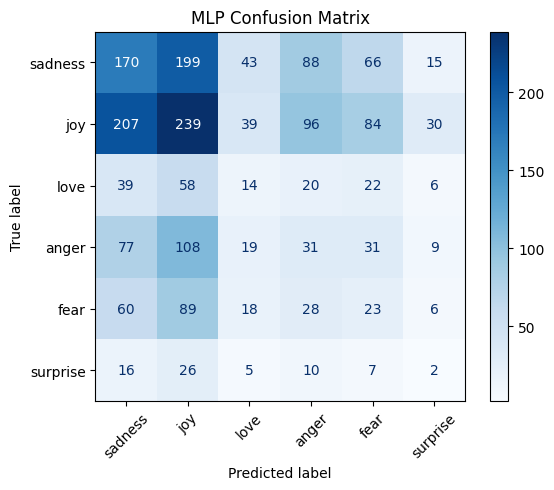

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

MLP_model.eval()

with torch.no_grad():
    logits = MLP_model(X_val_t)
    pred_ids = torch.argmax(logits, dim=1).cpu().numpy()

true_ids = np.array(y_test)

pred_labels = [label_names[i] for i in pred_ids]
true_labels = [label_names[i] for i in true_ids]

cm_mlp = confusion_matrix(
    true_labels,
    pred_labels,
    labels=label_names
)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=label_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("MLP Confusion Matrix")
plt.show()


<Figure size 800x800 with 0 Axes>

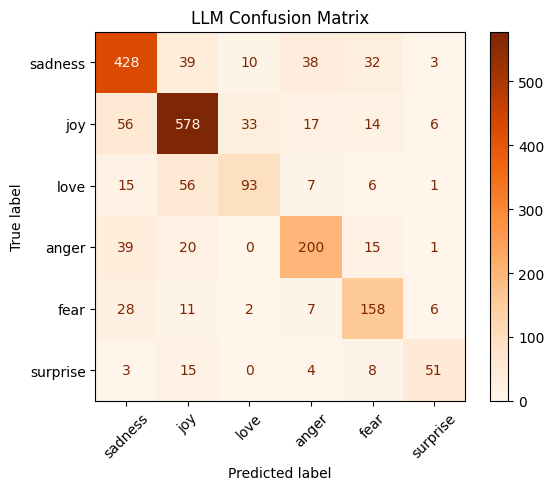

In [ ]:
cm_llm = confusion_matrix(
    actual,
    predicted,
    labels=label_names
)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_llm,
    display_labels=label_names
)

disp.plot(cmap="Oranges", xticks_rotation=45)

plt.title("LLM Confusion Matrix")
plt.show()